# Linear Regression - Practice

We will apply what you learned about linear regression for a new data set. 

The `Data` folder contains a `csv`-file containing information about CO$_2$ vehicle emissions for vehicles in Canada. 

You can now practice what you learned by 

1. loading the dataset into pandas
2. performing exploratory data analysis to understand
    - what the columns are?
    - descriptive statistics of numeric and text columns (e.g. value counts, mean, std)
3. make plots and calculate correlation coefficients to find linear correlations in the data
4. apply simple linear regression 
5. apply multiple linear regression 
6. explore the impact of the car type (a discrete variable) on CO$_2$ emissions

**Happy working!**

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats

In [15]:
CO2 = pd.read_csv(r"C:\Users\emmyr\OneDrive\OneDrive - James Madison University\Documents\ISAT_420\ISAT_420_S26_Shared\W12_Statistical_Models\Data\CO2 Emissions_Canada.csv")

In [17]:
CO2.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [18]:
CO2.describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


In [22]:
CO2['ES binned']=pd.cut(CO2['Engine Size(L)'],[1,2,3,4])
CO2

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),ES binned
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196,"(1, 2]"
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221,"(2, 3]"
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136,"(1, 2]"
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255,"(3, 4]"
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244,"(3, 4]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7380,VOLVO,XC40 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,10.7,7.7,9.4,30,219,"(1, 2]"
7381,VOLVO,XC60 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,11.2,8.3,9.9,29,232,"(1, 2]"
7382,VOLVO,XC60 T6 AWD,SUV - SMALL,2.0,4,AS8,Z,11.7,8.6,10.3,27,240,"(1, 2]"
7383,VOLVO,XC90 T5 AWD,SUV - STANDARD,2.0,4,AS8,Z,11.2,8.3,9.9,29,232,"(1, 2]"


<Axes: xlabel='Engine Size(L)', ylabel='CO2 Emissions(g/km)'>

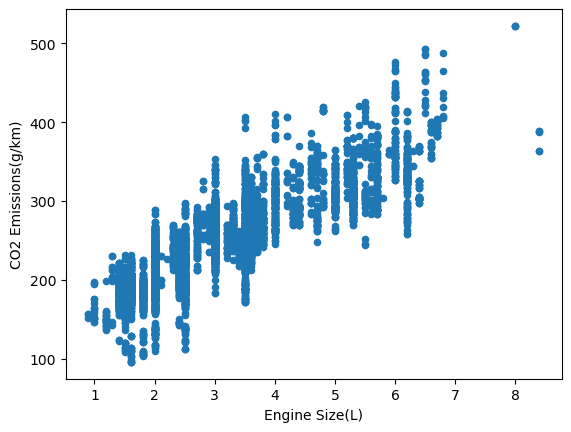

In [29]:
CO2.plot(kind = 'scatter', x='Engine Size(L)',y='CO2 Emissions(g/km)')

<Axes: xlabel='ES binned'>

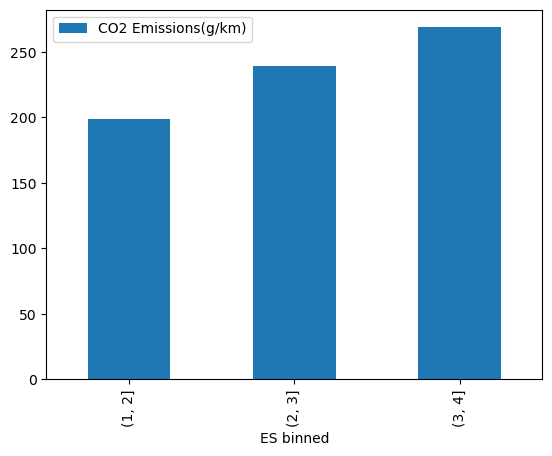

In [26]:
CO2[['ES binned', 'CO2 Emissions(g/km)']].groupby(by = 'ES binned').mean().plot.bar()